In [1]:
import sys
!"{sys.executable}" -m pip install nibabel


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Program Files\Python39\python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import pandas as pd
import nibabel as nib
import numpy as np

In [3]:
data_root = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200"

In [4]:
csv_files = glob.glob(os.path.join(data_root, "**/*.csv"), recursive=True)
dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        df['site'] = os.path.basename(os.path.dirname(file))
        dfs.append(df)
        print(f"Loaded {file} ({len(df)} rows)")
    except Exception as e:
        print(f"⚠️ Skipped {file}: {e}") 

phenotypic_data = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Combined phenotypic data: {phenotypic_data.shape[0]} subjects")


Loaded C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\Brown_TestRelease_phenotypic.csv (26 rows)
Loaded C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\KKI_phenotypic.csv (83 rows)
Loaded C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\NeuroIMAGE_phenotypic.csv (48 rows)
Loaded C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\NYU_phenotypic.csv (222 rows)
Loaded C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD2

In [5]:
phenotypic_data.head()

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,...,Full4 IQ,Med Status,QC_Rest_1,QC_Rest_2,QC_Rest_3,QC_Rest_4,QC_Anatomical_1,QC_Anatomical_2,site,ID
0,26001.0,2,1.0,16.92,1,pending,pending,pending,pending,pending,...,120.0,pending,1.0,NaN,NaN,NaN,1.0,NaN,ADHD200,NaN
1,26002.0,2,1.0,15.68,1,pending,pending,pending,pending,pending,...,107.0,pending,1.0,NaN,NaN,NaN,1.0,NaN,ADHD200,NaN
2,26004.0,2,0.0,14.99,1,pending,pending,pending,pending,pending,...,125.0,pending,1.0,NaN,NaN,NaN,1.0,NaN,ADHD200,NaN
3,26005.0,2,0.0,15.16,1,pending,pending,pending,pending,pending,...,126.0,pending,1.0,NaN,NaN,NaN,1.0,NaN,ADHD200,NaN
4,26009.0,2,1.0,16.91,0,pending,pending,pending,pending,pending,...,97.0,pending,1.0,NaN,NaN,NaN,1.0,NaN,ADHD200,NaN


In [6]:
sMRI_files = glob.glob(os.path.join(data_root, "**", "anat", "*T1*.nii*"), recursive=True)
print(f"✅ Found {len(sMRI_files)} sMRI files")

# Print a few examples
for f in sMRI_files[:5]:
    print(f)


✅ Found 960 sMRI files
C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\Brown\sub-0026001\ses-1\anat\sub-0026001_ses-1_run-1_T1w.nii.gz
C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\Brown\sub-0026002\ses-1\anat\sub-0026002_ses-1_run-1_T1w.nii.gz
C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\Brown\sub-0026004\ses-1\anat\sub-0026004_ses-1_run-1_T1w.nii.gz
C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\Brown\sub-0026005\ses-1\anat\sub-0026005_ses-1_run-1_T1w.nii.gz
C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi

In [7]:
sample_file = sMRI_files[0]
print("Loading:", sample_file)

img = nib.load(sample_file)
data = img.get_fdata()

print("Shape:", data.shape)
print("Voxel intensity range:", data.min(), "→", data.max())

Loading: C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\ADHD200\Brown\sub-0026001\ses-1\anat\sub-0026001_ses-1_run-1_T1w.nii.gz
Shape: (160, 240, 256)
Voxel intensity range: 0.0 → 812.0


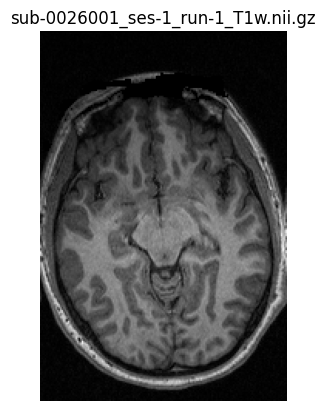

In [8]:
import matplotlib.pyplot as plt

slice_idx = data.shape[2] // 2
plt.imshow(data[:, :, slice_idx].T, cmap='gray', origin='lower')
plt.title(os.path.basename(sample_file))
plt.axis('off')
plt.show()

In [9]:
records = []
for f in sMRI_files:
    subject_id = os.path.basename(os.path.dirname(os.path.dirname(f)))  # e.g., sub001
    site = f.split(os.sep)[-4]  # extract site name (depends on depth)
    records.append({"site": site, "subject": subject_id, "sMRI_path": f})

sMRI_table = pd.DataFrame(records)
sMRI_table.head()

,site,subject,sMRI_path
0,sub-0026001,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,sub-0026002,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,sub-0026004,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,sub-0026005,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,sub-0026009,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [10]:
print(sMRI_table['site'].head(10))

0    sub-0026001
1    sub-0026002
2    sub-0026004
3    sub-0026005
4    sub-0026009
5    sub-0026014
6    sub-0026015
7    sub-0026016
8    sub-0026017
9    sub-0026022
Name: site, dtype: object


In [11]:
def format_subject_id(scan_id):
    # Remove decimals and convert to int
    scan_id = int(scan_id)
    # Add prefix 'sub-' and pad with zeros to match sMRI numeric part
    return f"sub-{scan_id:07d}"  # 7 digits after 'sub-'

In [12]:
phenotypic_data = phenotypic_data.dropna(subset=['ScanDir ID']).copy()
phenotypic_data['site'] = phenotypic_data['ScanDir ID'].apply(format_subject_id)

# Check
phenotypic_data[['ScanDir ID', 'site']].head()


,ScanDir ID,site
0,26001.0,sub-0026001
1,26002.0,sub-0026002
2,26004.0,sub-0026004
3,26005.0,sub-0026005
4,26009.0,sub-0026009


In [13]:
merged = pd.merge(
    phenotypic_data,
    sMRI_table,
    on='site',
    how='inner'
)

print("✅ Merged shape:", merged.shape)
merged.head()


✅ Merged shape: (666, 27)


,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,...,QC_Rest_1,QC_Rest_2,QC_Rest_3,QC_Rest_4,QC_Anatomical_1,QC_Anatomical_2,site,ID,subject,sMRI_path
0,26001.0,2,1.0,16.92,1,pending,pending,pending,pending,pending,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-0026001,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,26002.0,2,1.0,15.68,1,pending,pending,pending,pending,pending,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-0026002,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,26004.0,2,0.0,14.99,1,pending,pending,pending,pending,pending,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-0026004,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,26005.0,2,0.0,15.16,1,pending,pending,pending,pending,pending,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-0026005,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,26009.0,2,1.0,16.91,0,pending,pending,pending,pending,pending,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-0026009,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [14]:
phenotypic_data.at[0, 'ADHD Measure']

'pending'

In [15]:
phenotypic_data['ADHD Measure'].value_counts(dropna=False)

ADHD Measure
2          305
NaN        171
1           85
3           79
pending     26
Name: count, dtype: int64

In [16]:
# Loop through all columns and count 'pending' values
for col in phenotypic_data.columns:
    pending_count = (phenotypic_data[col] == 'pending').sum()
    if pending_count > 0:
        print(f"{col}: {pending_count}/{len(phenotypic_data)} pending")


DX: 26/666 pending
Secondary Dx : 26/666 pending
ADHD Measure: 26/666 pending
ADHD Index: 26/666 pending
Inattentive: 26/666 pending
Hyper/Impulsive: 26/666 pending
Med Status: 26/666 pending


In [17]:
# Replace 'pending' with NaN in all columns
phenotypic_data = phenotypic_data.replace('pending', pd.NA)

# Check which columns still have missing values
phenotypic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 666 entries, 0 to 716
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ScanDir ID       666 non-null    float64
 1   Site             666 non-null    int64  
 2   Gender           665 non-null    float64
 3   Age              666 non-null    float64
 4   Handedness       665 non-null    float64
 5   DX               640 non-null    object 
 6   Secondary Dx     90 non-null     object 
 7   ADHD Measure     469 non-null    object 
 8   ADHD Index       390 non-null    object 
 9   Inattentive      469 non-null    object 
 10  Hyper/Impulsive  469 non-null    object 
 11  IQ Measure       592 non-null    float64
 12  Verbal IQ        505 non-null    float64
 13  Performance IQ   505 non-null    float64
 14  Full2 IQ         89 non-null     float64
 15  Full4 IQ         618 non-null    float64
 16  Med Status       469 non-null    object 
 17  QC_Rest_1        660 

C:\Users\tharu\AppData\Local\Temp\ipykernel_9668\1322478117.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phenotypic_data = phenotypic_data.replace('pending', pd.NA)


In [18]:
# Loop through all columns and count 'pending' values
for col in phenotypic_data.columns:
    pending_count = (phenotypic_data[col] == 'pending').sum()
    if pending_count > 0:
        print(f"{col}: {pending_count}/{len(phenotypic_data)} pending")
    else:
        print("No 'pending' value in", col) 

No 'pending' value in ScanDir ID
No 'pending' value in Site
No 'pending' value in Gender
No 'pending' value in Age
No 'pending' value in Handedness
No 'pending' value in DX
No 'pending' value in Secondary Dx 
No 'pending' value in ADHD Measure
No 'pending' value in ADHD Index
No 'pending' value in Inattentive
No 'pending' value in Hyper/Impulsive
No 'pending' value in IQ Measure
No 'pending' value in Verbal IQ
No 'pending' value in Performance IQ
No 'pending' value in Full2 IQ
No 'pending' value in Full4 IQ
No 'pending' value in Med Status
No 'pending' value in QC_Rest_1
No 'pending' value in QC_Rest_2
No 'pending' value in QC_Rest_3
No 'pending' value in QC_Rest_4
No 'pending' value in QC_Anatomical_1
No 'pending' value in QC_Anatomical_2
No 'pending' value in site
No 'pending' value in ID


In [19]:
phenotypic_clean = phenotypic_data.dropna(subset=['ADHD Measure', 'Inattentive', 'Hyper/Impulsive']).copy()
print(f"Rows remaining: {len(phenotypic_clean)} / {len(phenotypic_data)}")

Rows remaining: 469 / 666


In [20]:
merged = pd.merge(
    phenotypic_clean,
    sMRI_table,
    on='site',
    how='inner'
)

print("✅ Merged shape:", merged.shape)
merged.head()

✅ Merged shape: (469, 27)


,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,...,QC_Rest_1,QC_Rest_2,QC_Rest_3,QC_Rest_4,QC_Anatomical_1,QC_Anatomical_2,site,ID,subject,sMRI_path
0,2371032.0,3,0.0,10.73,1.0,0,NaN,2,47,55,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-2371032,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,2026113.0,3,0.0,12.99,1.0,1,NaN,2,90,89,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-2026113,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,3434578.0,3,0.0,8.12,1.0,0,NaN,2,42,42,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-3434578,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,8628223.0,3,0.0,10.81,1.0,0,Simple phobia,2,42,49,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-8628223,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,1623716.0,3,0.0,12.65,1.0,1,NaN,2,87,90,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-1623716,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [21]:
merged['Secondary Dx '] = merged['Secondary Dx '].fillna("None")

In [22]:
merged['DX'].isna().sum()

np.int64(0)

In [23]:
merged['DX'].value_counts(dropna=False)

DX
0    263
1    123
3     78
2      5
Name: count, dtype: int64

| DX Value | Clinical Meaning                           |
| -------- | ------------------------------------------ |
| **0**    | Typically Developing Control (TDC)         |
| **1**    | ADHD – Combined Type                       |
| **2**    | ADHD – Predominantly Hyperactive/Impulsive |
| **3**    | ADHD – Predominantly Inattentive           |

##### These codes come from ADHD200 documentation and prior published analyses using the dataset.

In [24]:
merged.head()

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,...,QC_Rest_1,QC_Rest_2,QC_Rest_3,QC_Rest_4,QC_Anatomical_1,QC_Anatomical_2,site,ID,subject,sMRI_path
0,2371032.0,3,0.0,10.73,1.0,0,None,2,47,55,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-2371032,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,2026113.0,3,0.0,12.99,1.0,1,None,2,90,89,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-2026113,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,3434578.0,3,0.0,8.12,1.0,0,None,2,42,42,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-3434578,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,8628223.0,3,0.0,10.81,1.0,0,Simple phobia,2,42,49,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-8628223,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,1623716.0,3,0.0,12.65,1.0,1,None,2,87,90,...,1.0,NaN,NaN,NaN,1.0,NaN,sub-1623716,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [25]:
print("Shape (rows, columns):", merged.shape)
print("Number of rows:", len(merged))
print("Number of columns:", merged.shape[1])

Shape (rows, columns): (469, 27)
Number of rows: 469
Number of columns: 27


In [26]:
print(merged.columns.tolist())

['ScanDir ID', 'Site', 'Gender', 'Age', 'Handedness', 'DX', 'Secondary Dx ', 'ADHD Measure', 'ADHD Index', 'Inattentive', 'Hyper/Impulsive', 'IQ Measure', 'Verbal IQ', 'Performance IQ', 'Full2 IQ', 'Full4 IQ', 'Med Status', 'QC_Rest_1', 'QC_Rest_2', 'QC_Rest_3', 'QC_Rest_4', 'QC_Anatomical_1', 'QC_Anatomical_2', 'site', 'ID', 'subject', 'sMRI_path']


| **Column**                           | **Meaning**                                                     | **Typical Use / Importance**        | **Notes**                                                                              |
| ------------------------------------ | --------------------------------------------------------------- | ----------------------------------- | -------------------------------------------------------------------------------------- |
| **ScanDir ID**                       | Unique identifier for each subject’s scan folder                | ✅ *Important (for linking data)*    | Used to match subject to their MRI files. Not used as a feature for ML.                |
| **Site**                             | Indicates the acquisition site (e.g., NYU, OHSU, Peking, etc.)  | ⚠️ *Useful (as confound control)*   | MRI data can vary by site/scanner. You may need to control for site effects.           |
| **Gender**                           | Biological sex of the subject (0 = Female, 1 = Male, etc.)      | ✅ *Potentially important feature*   | Sex may affect ADHD prevalence and brain patterns.                                     |
| **Age**                              | Subject’s age (in years)                                        | ✅ *Highly important*                | ADHD symptoms and brain development are age-related. Often used as a control variable. |
| **Handedness**                       | 0 = Right, 1 = Left, 2 = Ambidextrous                           | ⚠️ *Sometimes useful*               | Brain asymmetry can relate to handedness, but often optional.                          |
| **DX**                               | Diagnosis — typically 0 = Control, 1 = ADHD                     | ✅ *Crucial (target label)*          | This is your **main dependent variable** for classification.                           |
| **Secondary Dx**                     | Any additional comorbid diagnosis (e.g., anxiety, ODD)          | ⚠️ *Optional*                       | Can be used for comorbidity analysis, but often sparse or missing.                     |
| **ADHD Measure**                     | Type of ADHD diagnostic tool used (e.g., K-SADS, Conners, etc.) | ⚠️ *Optional*                       | Useful if you’re analyzing measurement differences, not for imaging model.             |
| **ADHD Index**                       | Quantitative ADHD severity score                                | ✅ *Very useful*                     | Can be used for regression or to categorize severity (mild/moderate/severe).           |
| **Inattentive**                      | Subscore for inattentive symptoms                               | ✅ *Important sub-feature*           | Part of ADHD symptom profile — can be used for subtype prediction.                     |
| **Hyper/Impulsive**                  | Subscore for hyperactive/impulsive symptoms                     | ✅ *Important sub-feature*           | Along with “Inattentive”, defines ADHD presentation.                                   |
| **IQ Measure**                       | Which IQ test was used (e.g., WISC, WASI, etc.)                 | ⚠️ *Low importance*                 | Useful for understanding IQ test differences but not predictive.                       |
| **Verbal IQ**                        | Subject’s verbal IQ score                                       | ✅ *Relevant for cognitive analysis* | Can be used as covariate or secondary feature.                                         |
| **Performance IQ**                   | Nonverbal IQ (e.g., problem-solving)                            | ✅ *Relevant*                        | Similar use as Verbal IQ.                                                              |
| **Full2 IQ / Full4 IQ**              | Variants of total IQ score                                      | ⚠️ *Redundant*                      | If both exist, usually one suffices.                                                   |
| **Med Status**                       | Medication status (0 = none, 1 = medicated)                     | ✅ *Important confound*              | Medication affects fMRI activation — must control for it.                              |
| **QC_Rest_1 – QC_Rest_4**            | Quality control flags for resting-state fMRI                    | ⚠️ *Useful for filtering data*      | 1 = good, 0 = poor quality; use to exclude poor scans.                                 |
| **QC_Anatomical_1, QC_Anatomical_2** | Quality control for anatomical (sMRI) scans                     | ⚠️ *Useful for filtering data*      | Ensure only high-quality scans are used.                                               |
| **site**                             | Duplicate of “Site”                                             | ❌ *Remove (redundant)*              | You can drop this column.                                                              |
| **ID**                               | Another identifier, sometimes same as “ScanDir ID”              | ❌ *Remove (redundant)*              | Keep only one unique ID column.                                                        |
| **subject**                          | Subject folder name (e.g., “sub-0026001”)                       | ✅ *Important for linking to files*  | Needed to match MRI images to metadata.                                                |
| **sMRI_path**                        | File path to structural MRI file                                | ✅ *Critical for loading images*     | Required when you load and preprocess MRI scans.                                       |


In [27]:
import os

# Check for missing sMRI paths
print("🔍 Checking for missing sMRI paths...")
missing_paths = merged['sMRI_path'].isna().sum()
print(f"Missing sMRI paths: {missing_paths}")

# Verify whether each path actually exists
merged['file_exists'] = merged['sMRI_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)

# Count missing or invalid file paths
invalid_count = (~merged['file_exists']).sum()
print(f"❌ Subjects with missing or invalid sMRI files: {invalid_count}")

# Remove rows with invalid or missing sMRI paths
merged = merged[merged['file_exists'] == True].drop(columns=['file_exists'])
print(f"✅ Final dataset after removing missing sMRI links: {len(merged)} subjects")

🔍 Checking for missing sMRI paths...
Missing sMRI paths: 0
❌ Subjects with missing or invalid sMRI files: 0
✅ Final dataset after removing missing sMRI links: 469 subjects


# EDA

In [28]:
merged.info()
merged.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ScanDir ID       469 non-null    float64
 1   Site             469 non-null    int64  
 2   Gender           468 non-null    float64
 3   Age              469 non-null    float64
 4   Handedness       468 non-null    float64
 5   DX               469 non-null    object 
 6   Secondary Dx     469 non-null    object 
 7   ADHD Measure     469 non-null    object 
 8   ADHD Index       390 non-null    object 
 9   Inattentive      469 non-null    object 
 10  Hyper/Impulsive  469 non-null    object 
 11  IQ Measure       469 non-null    float64
 12  Verbal IQ        390 non-null    float64
 13  Performance IQ   390 non-null    float64
 14  Full2 IQ         0 non-null      float64
 15  Full4 IQ         469 non-null    float64
 16  Med Status       469 non-null    object 
 17  QC_Rest_1       

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,...,QC_Rest_1,QC_Rest_2,QC_Rest_3,QC_Rest_4,QC_Anatomical_1,QC_Anatomical_2,site,ID,subject,sMRI_path
count,4.690000e+02,469.000000,468.000000,469.000000,468.000000,469.0,469,469.0,390.0,469.0,...,463.000000,266.000000,79.000000,1.0,468.000000,136.000000,469,0.0,469,469
unique,NaN,NaN,NaN,NaN,NaN,4.0,57,3.0,69.0,78.0,...,NaN,NaN,NaN,NaN,NaN,NaN,469,NaN,1,469
top,NaN,NaN,NaN,NaN,NaN,0.0,None,2.0,42.0,42.0,...,NaN,NaN,NaN,NaN,NaN,NaN,sub-9499804,NaN,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
freq,NaN,NaN,NaN,NaN,NaN,263.0,380,305.0,49.0,29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,469,1
mean,2.486841e+06,4.089552,0.568376,10.822367,-12.007521,NaN,NaN,NaN,NaN,NaN,...,-9.922246,0.710526,0.708861,1.0,-9.724359,0.926471,NaN,NaN,NaN,NaN
std,2.369267e+06,1.718575,0.495833,2.496396,112.598954,NaN,NaN,NaN,NaN,NaN,...,103.455694,0.454373,0.457190,NaN,102.914628,0.261968,NaN,NaN,NaN,NaN
min,1.000100e+04,1.000000,0.000000,7.170000,-999.000000,NaN,NaN,NaN,NaN,NaN,...,-999.000000,0.000000,0.000000,1.0,-999.000000,0.000000,NaN,NaN,NaN,NaN
25%,1.011800e+04,3.000000,0.000000,8.910000,0.647500,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,NaN
50%,2.155356e+06,5.000000,1.000000,10.330000,1.000000,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,3.554582e+06,5.000000,1.000000,12.100000,1.000000,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,NaN


In [29]:
duplicates = merged.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

merged = merged.drop_duplicates()

Number of duplicate rows: 0


Text(0.5, 1.0, 'Age Distribution')

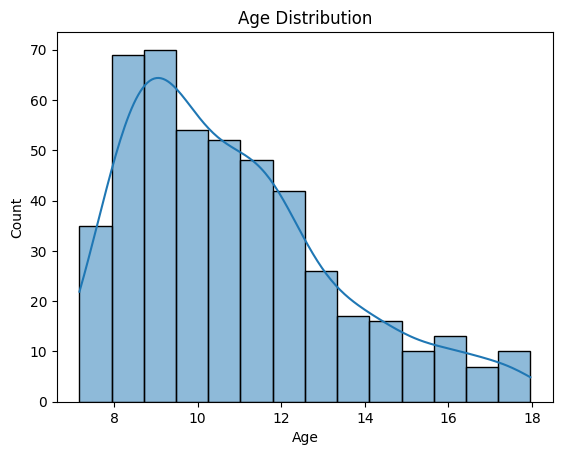

In [30]:
import seaborn as sns

# Age distribution
sns.histplot(merged['Age'], kde=True)
plt.title("Age Distribution")

Text(0.5, 1.0, 'Gender Distribution')

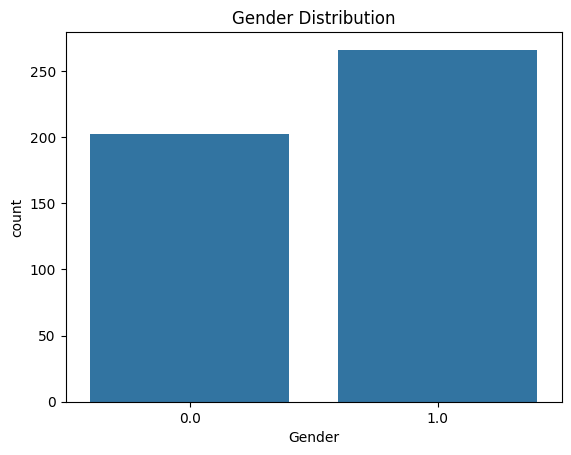

In [31]:
# Gender balance
sns.countplot(x='Gender', data=merged)
plt.title("Gender Distribution")

Text(0.5, 1.0, 'Diagnosis (DX) Distribution')

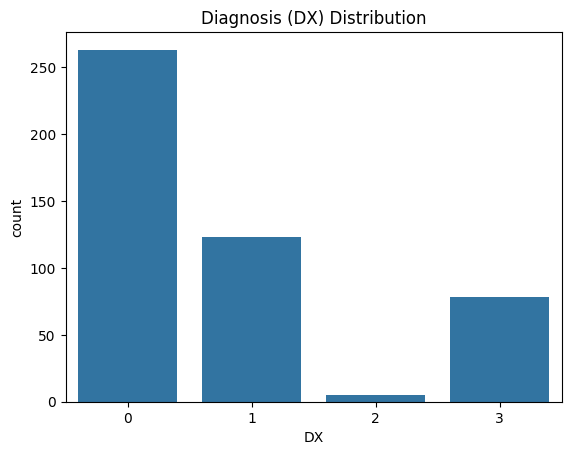

In [32]:
# Diagnosis counts
sns.countplot(x='DX', data=merged)
plt.title("Diagnosis (DX) Distribution")

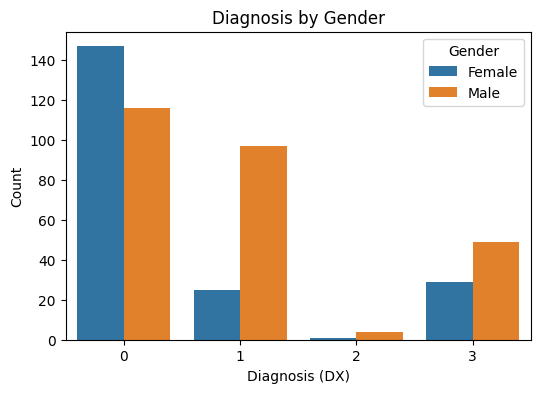

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='DX', hue='Gender', data=merged)
plt.title("Diagnosis by Gender")
plt.xlabel("Diagnosis (DX)")
plt.ylabel("Count")
plt.legend(title="Gender", labels=["Female", "Male"])
plt.show()

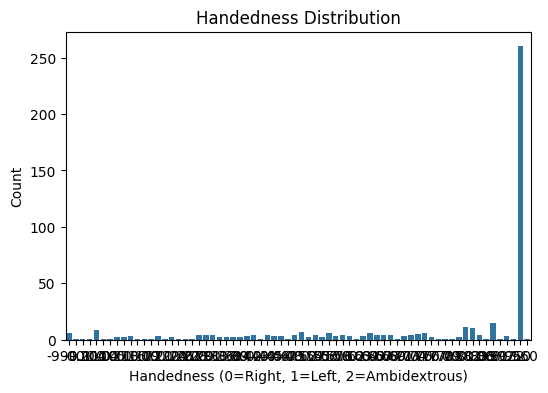

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='Handedness', data=merged)
plt.title("Handedness Distribution")
plt.xlabel("Handedness (0=Right, 1=Left, 2=Ambidextrous)")
plt.ylabel("Count")
plt.show()

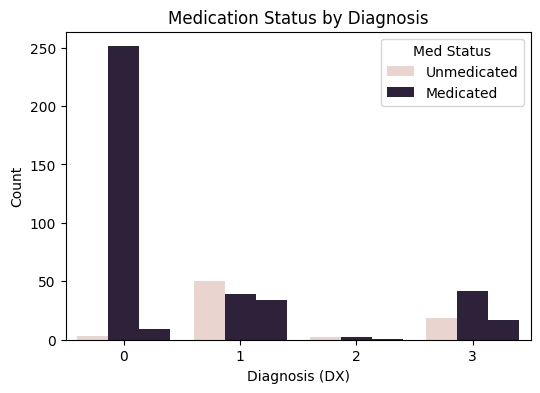

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='DX', hue='Med Status', data=merged)
plt.title("Medication Status by Diagnosis")
plt.xlabel("Diagnosis (DX)")
plt.ylabel("Count")
plt.legend(title="Med Status", labels=["Unmedicated", "Medicated"])
plt.show()

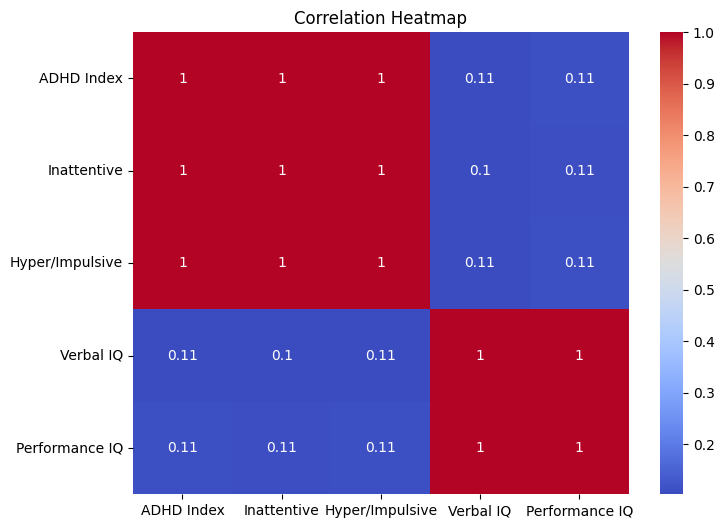

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(merged[['ADHD Index','Inattentive','Hyper/Impulsive','Verbal IQ','Performance IQ']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

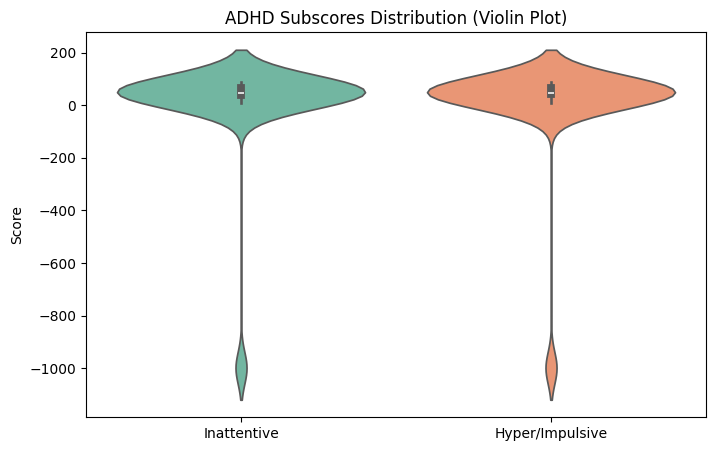

In [37]:
plt.figure(figsize=(8,5))
sns.violinplot(data=merged[['Inattentive', 'Hyper/Impulsive']], palette="Set2")
plt.title("ADHD Subscores Distribution (Violin Plot)")
plt.ylabel("Score")
plt.show()

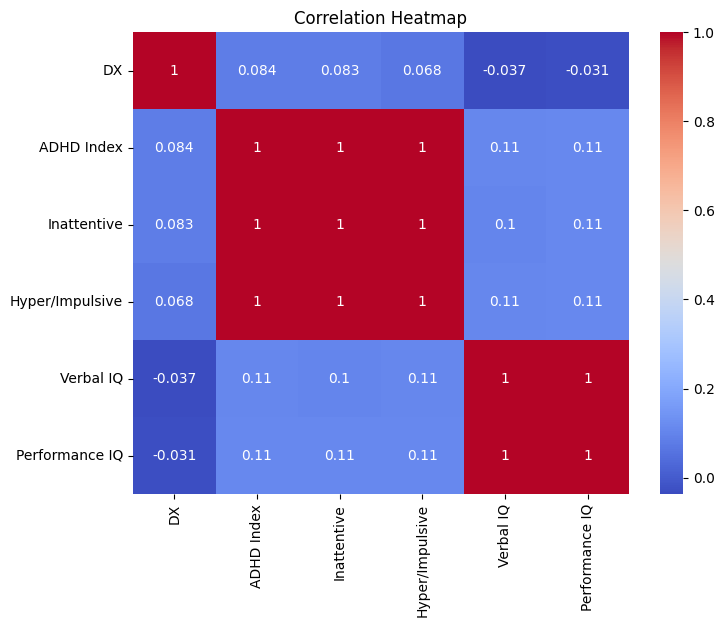

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(merged[['DX', 'ADHD Index','Inattentive','Hyper/Impulsive','Verbal IQ','Performance IQ']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
# Replace all 'pending' strings with NaN
merged.replace('pending', np.nan, inplace=True)

# Check missing values again
merged.isna().sum()

ScanDir ID           0
Site                 0
Gender               1
Age                  0
Handedness           1
DX                   0
Secondary Dx         0
ADHD Measure         0
ADHD Index          79
Inattentive          0
Hyper/Impulsive      0
IQ Measure           0
Verbal IQ           79
Performance IQ      79
Full2 IQ           469
Full4 IQ             0
Med Status           0
QC_Rest_1            6
QC_Rest_2          203
QC_Rest_3          390
QC_Rest_4          468
QC_Anatomical_1      1
QC_Anatomical_2    333
site                 0
ID                 469
subject              0
sMRI_path            0
dtype: int64

In [40]:
# Fill categorical missing values
for col in ['Gender', 'Handedness', 'QC_Anatomical_1']:
    merged[col] = merged[col].fillna(merged[col].mode()[0])

# Fill numeric missing values
for col in ['ADHD Index', 'Verbal IQ', 'Performance IQ']:
    merged[col] = merged[col].fillna(merged[col].median())

# verify
merged.isna().sum()

C:\Users\tharu\AppData\Local\Temp\ipykernel_9668\673069669.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged[col] = merged[col].fillna(merged[col].median())


ScanDir ID           0
Site                 0
Gender               0
Age                  0
Handedness           0
DX                   0
Secondary Dx         0
ADHD Measure         0
ADHD Index           0
Inattentive          0
Hyper/Impulsive      0
IQ Measure           0
Verbal IQ            0
Performance IQ       0
Full2 IQ           469
Full4 IQ             0
Med Status           0
QC_Rest_1            6
QC_Rest_2          203
QC_Rest_3          390
QC_Rest_4          468
QC_Anatomical_1      0
QC_Anatomical_2    333
site                 0
ID                 469
subject              0
sMRI_path            0
dtype: int64

In [41]:
merged = merged.drop(columns=['Full2 IQ', 'QC_Rest_2','QC_Rest_3','QC_Rest_4','QC_Anatomical_2', 'site','ID'])
# verify
merged.isna().sum()

ScanDir ID         0
Site               0
Gender             0
Age                0
Handedness         0
DX                 0
Secondary Dx       0
ADHD Measure       0
ADHD Index         0
Inattentive        0
Hyper/Impulsive    0
IQ Measure         0
Verbal IQ          0
Performance IQ     0
Full4 IQ           0
Med Status         0
QC_Rest_1          6
QC_Anatomical_1    0
subject            0
sMRI_path          0
dtype: int64

#### validation to drop the data columns
- Columns with extremely high missing rates provide no reliable statistical signal and introduce bias if retained.

Columns with extremely high missingness, including Full2 IQ, multiple resting-state quality control variables, and site-specific identifiers, were removed to prevent unreliable imputation and noise introduction. These features were either entirely missing, irrelevant to the structural MRI–focused analysis, or inconsistent across acquisition sites. Removing them improves data integrity, reduces bias, and ensures compatibility with external neurodevelopmental datasets such as ABIDE and OpenNeuro, thereby supporting robust and generalizable modeling.

In [42]:
import sys
!"{sys.executable}" -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Program Files\Python39\python.exe -m pip install --upgrade pip


In [43]:
# For numeric imputation
from sklearn.impute import SimpleImputer

# For encoding categorical columns
from sklearn.preprocessing import LabelEncoder

# For scaling numerical features
from sklearn.preprocessing import StandardScaler

In [44]:
num_cols = merged.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='mean')
merged[num_cols] = imputer.fit_transform(merged[num_cols])
merged

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,Hyper/Impulsive,IQ Measure,Verbal IQ,Performance IQ,Full4 IQ,Med Status,QC_Rest_1,QC_Anatomical_1,subject,sMRI_path
0,2371032.0,3.0,0.0,10.73,1.0,0,None,2,47.0,55,43,1.0,121.0,119.0,122.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,2026113.0,3.0,0.0,12.99,1.0,1,None,2,90.0,89,78,1.0,122.0,108.0,106.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,3434578.0,3.0,0.0,8.12,1.0,0,None,2,42.0,42,43,1.0,85.0,98.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,8628223.0,3.0,0.0,10.81,1.0,0,Simple phobia,2,42.0,49,49,1.0,85.0,86.0,97.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,1623716.0,3.0,0.0,12.65,1.0,1,None,2,87.0,90,90,1.0,89.0,88.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,7333005.0,6.0,1.0,9.00,1.0,1,None,3,47.0,85,76,2.0,110.0,106.0,108.0,-999,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
465,8064456.0,6.0,0.0,9.25,1.0,0,None,3,47.0,48,47,2.0,110.0,106.0,118.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
466,8218392.0,6.0,1.0,8.33,1.0,0,None,3,47.0,59,42,2.0,110.0,106.0,104.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
467,8720244.0,6.0,0.0,10.33,1.0,3,None,3,47.0,68,60,2.0,110.0,106.0,82.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [45]:
cat_cols = merged.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
merged[cat_cols] = imputer_cat.fit_transform(merged[cat_cols])
merged

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,Hyper/Impulsive,IQ Measure,Verbal IQ,Performance IQ,Full4 IQ,Med Status,QC_Rest_1,QC_Anatomical_1,subject,sMRI_path
0,2371032.0,3.0,0.0,10.73,1.0,0,None,2,47.0,55,43,1.0,121.0,119.0,122.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,2026113.0,3.0,0.0,12.99,1.0,1,None,2,90.0,89,78,1.0,122.0,108.0,106.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,3434578.0,3.0,0.0,8.12,1.0,0,None,2,42.0,42,43,1.0,85.0,98.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,8628223.0,3.0,0.0,10.81,1.0,0,Simple phobia,2,42.0,49,49,1.0,85.0,86.0,97.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,1623716.0,3.0,0.0,12.65,1.0,1,None,2,87.0,90,90,1.0,89.0,88.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,7333005.0,6.0,1.0,9.00,1.0,1,None,3,47.0,85,76,2.0,110.0,106.0,108.0,-999,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
465,8064456.0,6.0,0.0,9.25,1.0,0,None,3,47.0,48,47,2.0,110.0,106.0,118.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
466,8218392.0,6.0,1.0,8.33,1.0,0,None,3,47.0,59,42,2.0,110.0,106.0,104.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
467,8720244.0,6.0,0.0,10.33,1.0,3,None,3,47.0,68,60,2.0,110.0,106.0,82.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [46]:
# label_enc = LabelEncoder()
# for col in ['Gender', 'Handedness', 'Site', 'Med Status', 'DX', 'Secondary Dx ']:
#     if col in merged.columns:
#         merged[col] = label_enc.fit_transform(merged[col].astype(str))
# merged

from sklearn.preprocessing import LabelEncoder

le_dx = LabelEncoder()
merged['DX'] = le_dx.fit_transform(merged['DX'].astype(str))
merged

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,Hyper/Impulsive,IQ Measure,Verbal IQ,Performance IQ,Full4 IQ,Med Status,QC_Rest_1,QC_Anatomical_1,subject,sMRI_path
0,2371032.0,3.0,0.0,10.73,1.0,0,None,2,47.0,55,43,1.0,121.0,119.0,122.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,2026113.0,3.0,0.0,12.99,1.0,1,None,2,90.0,89,78,1.0,122.0,108.0,106.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,3434578.0,3.0,0.0,8.12,1.0,0,None,2,42.0,42,43,1.0,85.0,98.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,8628223.0,3.0,0.0,10.81,1.0,0,Simple phobia,2,42.0,49,49,1.0,85.0,86.0,97.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,1623716.0,3.0,0.0,12.65,1.0,1,None,2,87.0,90,90,1.0,89.0,88.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,7333005.0,6.0,1.0,9.00,1.0,1,None,3,47.0,85,76,2.0,110.0,106.0,108.0,-999,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
465,8064456.0,6.0,0.0,9.25,1.0,0,None,3,47.0,48,47,2.0,110.0,106.0,118.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
466,8218392.0,6.0,1.0,8.33,1.0,0,None,3,47.0,59,42,2.0,110.0,106.0,104.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
467,8720244.0,6.0,0.0,10.33,1.0,3,None,3,47.0,68,60,2.0,110.0,106.0,82.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [48]:
merged['DX'] = merged['DX'].apply(lambda x: 0 if x == 0 else 1)
merged.head(10)

,ScanDir ID,Site,Gender,Age,Handedness,DX,Secondary Dx,ADHD Measure,ADHD Index,Inattentive,Hyper/Impulsive,IQ Measure,Verbal IQ,Performance IQ,Full4 IQ,Med Status,QC_Rest_1,QC_Anatomical_1,subject,sMRI_path
0,2371032.0,3.0,0.0,10.73,1.0,0,None,2,47.0,55,43,1.0,121.0,119.0,122.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
1,2026113.0,3.0,0.0,12.99,1.0,1,None,2,90.0,89,78,1.0,122.0,108.0,106.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
2,3434578.0,3.0,0.0,8.12,1.0,0,None,2,42.0,42,43,1.0,85.0,98.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
3,8628223.0,3.0,0.0,10.81,1.0,0,Simple phobia,2,42.0,49,49,1.0,85.0,86.0,97.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
4,1623716.0,3.0,0.0,12.65,1.0,1,None,2,87.0,90,90,1.0,89.0,88.0,89.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
5,1594156.0,3.0,1.0,12.87,1.0,0,Simple Phobia,2,54.0,55,57,1.0,124.0,104.0,108.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
6,2930625.0,3.0,1.0,9.97,1.0,0,None,2,40.0,40,50,1.0,91.0,127.0,106.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
7,3154996.0,3.0,1.0,11.65,1.0,1,None,2,64.0,74,58,1.0,93.0,98.0,88.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
8,3160561.0,3.0,1.0,11.95,1.0,1,None,2,71.0,62,70,1.0,93.0,108.0,99.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...
9,4275075.0,3.0,0.0,10.50,1.0,1,None,2,87.0,75,69,1.0,93.0,100.0,94.0,1,1.0,1.0,ses-1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...


In [49]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe_cols = ['Gender', 'Handedness', 'Site', 'Med Status', 'Secondary Dx ']

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = ohe.fit_transform(merged[ohe_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=merged.index
)

# Drop original categorical columns
merged = merged.drop(columns=ohe_cols)

# Add encoded columns back
merged = pd.concat([merged, encoded_df], axis=1)

In [50]:
from sklearn.ensemble import RandomForestClassifier

# categorical_cols = ['Gender', 'Handedness', 'Site', 'Med Status', 'Secondary Dx ']
# X_cat = pd.get_dummies(merged[categorical_cols], drop_first=True)
# y = merged['DX']

# # Combine with numeric columns
# X_num = merged[num_cols]
# X_final = pd.concat([X_num, X_cat], axis=1)

# # Train RF
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X_final, y)

# # Feature importance
# importances = pd.Series(rf.feature_importances_, index=X_final.columns).sort_values(ascending=False)
# print(importances)
# important_features = importances.sort_values(ascending=False)


In [51]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data
X = merged.drop(columns=['DX', 'sMRI_path', 'subject', 'ScanDir ID'])
y = merged['DX']

# Scale numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=['float64', 'int64']))

# Train a Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Get only numeric columns used for training
num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Feature importance for numeric columns only
importances = pd.Series(rf.feature_importances_, index=num_cols)
important_features = importances.sort_values(ascending=False)

print("✅ Numeric Feature Importance:\n", important_features)


✅ Numeric Feature Importance:
 ADHD Index                                                          2.484076e-01
Med Status_1                                                        1.201519e-01
Full4 IQ                                                            8.890962e-02
Age                                                                 8.293199e-02
Med Status_-999                                                     7.015176e-02
                                                                        ...     
Secondary Dx _possible learning disorder                            1.492779e-05
Secondary Dx _social anxiety disorder; specific phobia              4.076914e-06
Secondary Dx _disruptive behavior disorder-NOS; possible math LD    1.471166e-06
Handedness_0.24                                                     9.875270e-08
Secondary Dx _past major depressive episode                         0.000000e+00
Length: 142, dtype: float64


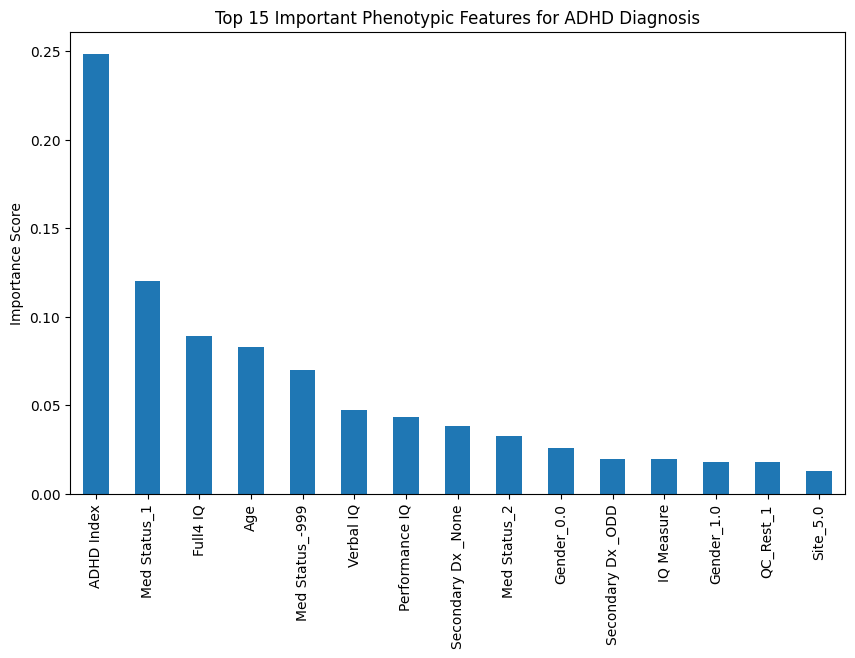

In [52]:
plt.figure(figsize=(10,6))
important_features.head(15).plot(kind='bar')
plt.title("Top 15 Important Phenotypic Features for ADHD Diagnosis")
plt.ylabel("Importance Score")
plt.show()

In [53]:
threshold = 0.01
selected_features = important_features[important_features > threshold].index.tolist()
cleaned_df = merged[selected_features + ['DX', 'sMRI_path', 'subject', 'ScanDir ID', 'ADHD Measure', 'Inattentive', 'Hyper/Impulsive']]

In [54]:
cleaned_df

,ADHD Index,Med Status_1,Full4 IQ,Age,Med Status_-999,Verbal IQ,Performance IQ,Secondary Dx _None,Med Status_2,Gender_0.0,...,QC_Rest_1,Site_5.0,Site_3.0,DX,sMRI_path,subject,ScanDir ID,ADHD Measure,Inattentive,Hyper/Impulsive
0,47.0,1.0,122.0,10.73,0.0,121.0,119.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,2371032.0,2,55,43
1,90.0,1.0,106.0,12.99,0.0,122.0,108.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,2026113.0,2,89,78
2,42.0,1.0,89.0,8.12,0.0,85.0,98.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,3434578.0,2,42,43
3,42.0,1.0,97.0,10.81,0.0,85.0,86.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,8628223.0,2,49,49
4,87.0,1.0,89.0,12.65,0.0,89.0,88.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,1623716.0,2,90,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,47.0,0.0,108.0,9.00,1.0,110.0,106.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,7333005.0,3,85,76
465,47.0,1.0,118.0,9.25,0.0,110.0,106.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,8064456.0,3,48,47
466,47.0,1.0,104.0,8.33,0.0,110.0,106.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,8218392.0,3,59,42
467,47.0,1.0,82.0,10.33,0.0,110.0,106.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1,C:\Users\tharu\Desktop\Starlight\FYP\Cross-Dis...,ses-1,8720244.0,3,68,60


In [55]:
# Save the preprocessed phenomic dataset to CSV
cleaned_df.to_csv(
    "ADHD200_Preprocessed_Phenomic_Dataset.csv",
    index=False
)

# sMRI Data Preprocessing

In [ ]:
import nibabel as nib
import numpy as np
import os

# Example: load a single sMRI
img_path = merged['sMRI_path'].iloc[0]  # path from your dataframe
img = nib.load(img_path)
img_data = img.get_fdata()

print("Shape:", img_data.shape)
print("Voxel intensity range:", img_data.min(), "→", img_data.max())

### Normalize voxel intensities

In [ ]:
# Min-Max normalization to [0, 1]
img_data_norm = (img_data - img_data.min()) / (img_data.max() - img_data.min())
print("Normalized intensity range:", img_data_norm.min(), "→", img_data_norm.max())

In [ ]:
img_data_z = (img_data - img_data.mean()) / img_data.std()
img_data_z

### Resize / crop

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # True if GPU is ready

In [ ]:
!where python

In [ ]:
import torch
import torch.nn.functional as F

# Convert to torch tensor
img_tensor = torch.tensor(img_data_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # shape: (1,1,D,H,W)

# Resize using trilinear interpolation
img_resized = F.interpolate(img_tensor, size=(128,128,128), mode='trilinear', align_corners=False)

# Remove extra dims
img_resized = img_resized.squeeze().numpy()
print("Resized shape:", img_resized.shape)

### Skull-stripping / brain masking

In [ ]:
import torch
import torch.nn.functional as F

# Convert to torch tensor
img_tensor = torch.tensor(img_data_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # shape: (1,1,D,H,W)

# Resize using trilinear interpolation
img_resized = F.interpolate(img_tensor, size=(128,128,128), mode='trilinear', align_corners=False)

# Remove extra dims
img_resized = img_resized.squeeze().numpy()
print("Resized shape:", img_resized.shape)


### Augmentation (for deep learning)

or CNN/RNN-based models, you can apply 3D augmentations:

Random rotation / flipping

Gaussian noise

Random zoom / cropping

In [ ]:
import sys
!"{sys.executable}" -m pip install torchio

In [ ]:
# import torchio as tio

# transform = tio.Compose([
#     tio.RandomFlip(axes=(0,1,2), flip_probability=0.5),
#     tio.RandomAffine(scales=(0.9,1.1), degrees=10)
# ])

# img_aug = transform(tio.ScalarImage(tensor=img_resized[np.newaxis]))
# img_aug = img_aug.data.squeeze().numpy()


In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# # Load 3D MRI image (.nii or .nii.gz)
# img = nib.load("path_to_your_image.nii")
# data = img.get_fdata()

# Choose a middle slice along X (sagittal view)
sagittal_slice = data[data.shape[0] // 2, :, :]

# Rotate or flip to get the desired orientation
rotated = np.rot90(sagittal_slice)

# Plot it
plt.imshow(rotated, cmap='gray')
plt.title("Sagittal View (2D Projection)")
plt.axis('off')
plt.show()


In [ ]:
# Axial (top-down)
axial_slice = data[:, :, data.shape[2] // 2]

# Coronal (front)
coronal_slice = data[:, data.shape[1] // 2, :] 
